In [ ]:
# %%

from einops import rearrange
import torch
from PIL import Image
import matplotlib.pyplot as plt

from ncut_pytorch import Ncut, kway_ncut

from extract_features import extract_dino_image_embeds, dino_img_transform

plt.rcParams['font.family'] = 'monospace'

/usr/local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# %%

def load_images_helper(pil_images):
    if isinstance(pil_images[0], str):
        pil_images = [Image.open(image) for image in pil_images]
    # convert to RGB
    pil_images = [image.convert("RGB") for image in pil_images]
    return pil_images

image_paths = ["./images/playviolin_hr.png", "./images/playguitar_hr.png"]

images = load_images_helper(image_paths)
images_tensor = torch.stack([dino_img_transform(image) for image in images])
dino_image_embeds = extract_dino_image_embeds(images_tensor)[:, 1:, :]
b, l, c = dino_image_embeds.shape
h = w = int(l**0.5)
features = rearrange(dino_image_embeds, 'b l c -> (b l) c')

print(f'b: {b}, h: {h}, w: {w}')
print(features.shape)

Using cache found in /home/user/.cache/torch/hub/facebookresearch_dino_main


b: 2, h: 32, w: 32
torch.Size([2048, 768])


In [ ]:
# %%

def differentiable_kway_ncut(features, n_segment):
    assert features.requires_grad == True
    # A = affinity_from_features(features, distance='rbf', gamma=0.5)
    # eigvec, eigval = ncut(A, n_segment)
    eigvec = Ncut(n_eig=n_segment, track_grad=True).fit_transform(features)
    kway_eigvec = kway_ncut(eigvec)
    return eigvec, kway_eigvec

In [ ]:
# %%

features = features.clone()
features.requires_grad_(True)
n_segment = 4
eigvec, kway_eigvec = differentiable_kway_ncut(features, n_segment=n_segment)
print(eigvec.requires_grad)

True


In [ ]:
# %%

def channel_gradient_from_cluster(features, cluster_mask, kway_eigvec, cluster_idx):
    assert features.requires_grad == True
    if features.grad is not None:
        features.grad.zero_()
    loss = - kway_eigvec[cluster_mask, cluster_idx].abs().mean() 
    # maximize the absolute value of the eigvec
    loss.backward(retain_graph=True)
    grad = features.grad[cluster_mask].mean(0)  # C
    return grad

import matplotlib.pyplot as plt
def plot_channel_gradient(grad, cluster_mask, features, n_plot_images=None):
    n_images = len(images)
    n_plot_images = n_images if n_plot_images is None else n_plot_images
    
    cluster_mask = cluster_mask.reshape(n_images, h, w)
    features = features.reshape(n_images, h, w, -1)
    features = features.detach().cpu().numpy()
    
    grad_sorted = torch.argsort(grad, descending=False)
    
    fig, axes = plt.subplots(n_plot_images, 7, figsize=(14, 2*n_plot_images))
    for i in range(n_plot_images):
        axes[i, 0].imshow(images[i])
        axes[i, 1].imshow(cluster_mask[i])
        axes[i, 1].set_title(f"cluster mask")
        for top_k in range(5):
            ch_idx = grad_sorted[top_k]
            axes[i, top_k+2].imshow(features[i, :, :, ch_idx], cmap='viridis')
            axes[i, top_k+2].set_title(f"top{top_k} ch {ch_idx}")
    for ax in axes.flatten():
        ax.axis('off')
    plt.tight_layout()
    plt.show()

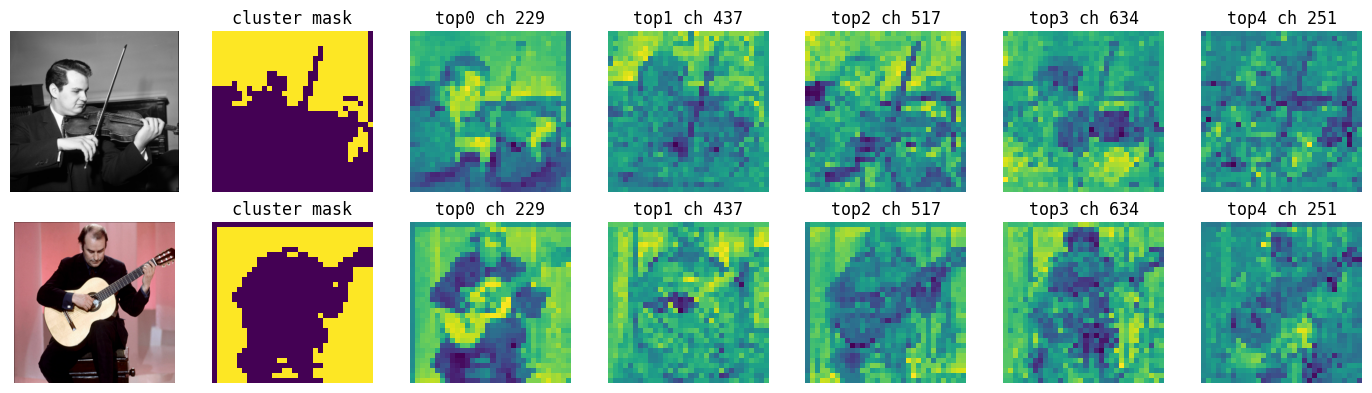

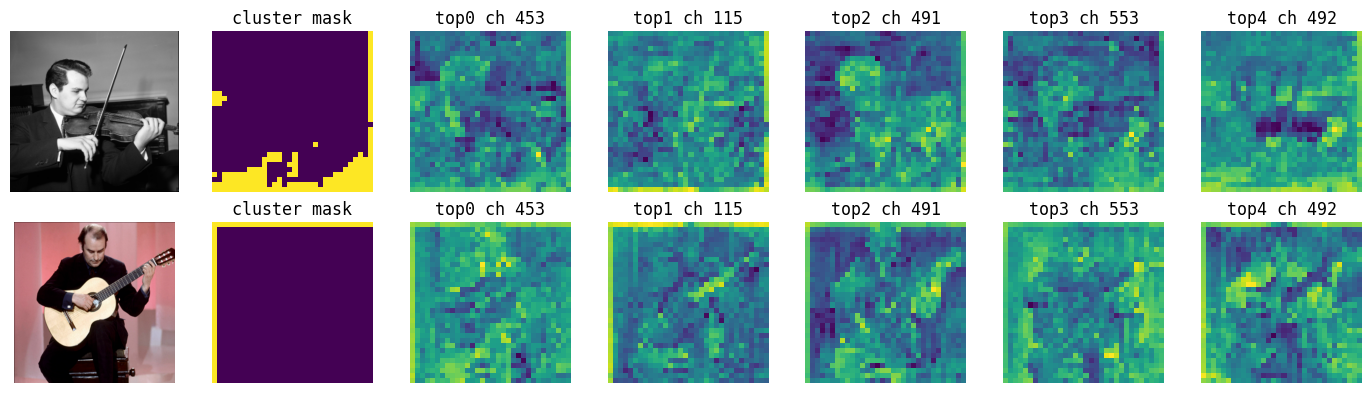

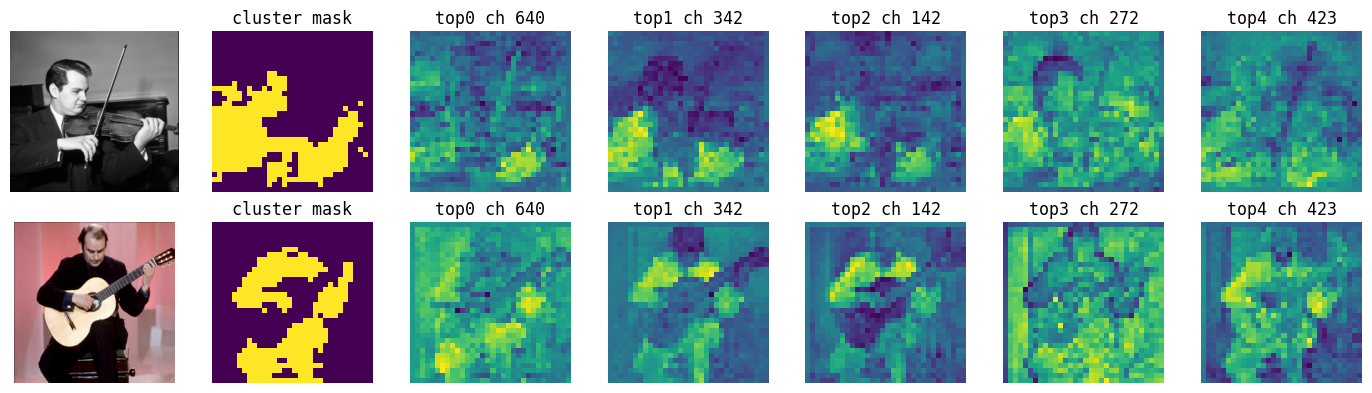

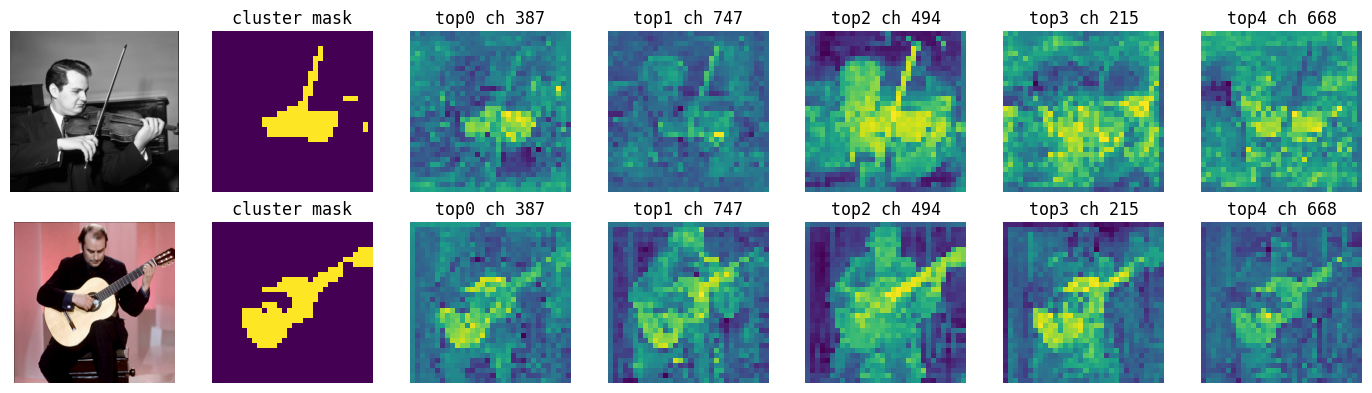

In [ ]:
# %%

for i in range(n_segment):
    cluster_mask = kway_eigvec.argmax(1) == i
    cluster_mask = cluster_mask.detach().cpu()
    grad = channel_gradient_from_cluster(features, cluster_mask, kway_eigvec, i)
    # plt.hist(grad.detach().cpu().numpy(), bins=100)
    # plt.show()
    plot_channel_gradient(grad, cluster_mask, features)

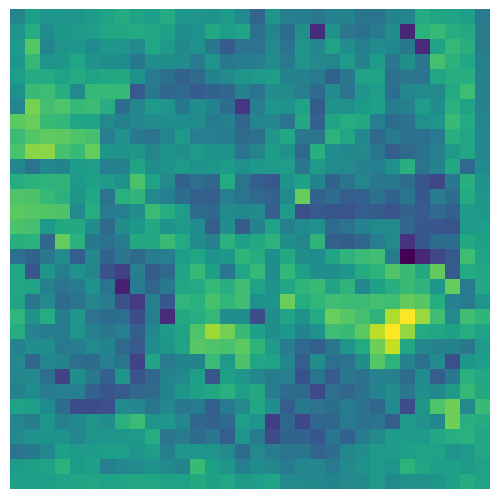

In [ ]:
# %%

# show ch 347
ch_idx = 62
_features = features.reshape(b, h, w, -1)
_features = _features.detach().cpu().numpy()
fig = plt.figure(frameon=False)
ax = plt.Axes(fig, [0., 0., 1., 1.])
ax.set_axis_off()
fig.add_axes(ax)
ax.imshow(_features[0, :, :, ch_idx])
plt.show()